# Seaborn - Einstieg

[Seaborn](https://seaborn.pydata.org/) ist eine Python Bibliothek zur statistischen Visualisierung von Daten und basiert auf [Matplotlib](https://matplotlib.org/).


Anhand eines Beispiel-Datensatzen "Trinkgelder in einem Restaurant" werden folgende Grafiken erstellt:
+ Verteilungsdichte einer Variablen - (Distribution Plots)
    + Histogramm 
    + Kerndichten-Schätzer 
    + Verteilungsfunktion  (empirical cumulative distribution functions - ECDF)
+ Verteilungsdichte von zwei Variablen
    + Scatterplot (in der Mitte) und zwei Histogramme (oberhalb und recht von der Mitte)
    + Hexagone-Plot
    + Regressionsgerade - linear regression
    + zwei-dimensioner Kerndichtenschätzer
+ Matrix mit Histogrammen und Scatterplots - Pairplot 
    + Spalten mit Kategorien in den Plot einbauen
+ Darstellung von Variablen mit Kategorien - Categorical Plots
    + Säulendiagramme - bar charts
    + Boxplot 
+ Matrix Plots - Heatmaps


Hier eine Übersicht über die Funktionen von Seaborn:
![function_overview](http://seaborn.pydata.org/_images/function_overview_8_0.png)

Seaborn unterscheidet zwei Arten von Subplots:
+ AxesSubplot = ein einzelner Plotbereich.
+ FacetGrid = ein ganzes Raster aus mehreren Plotbereichen

Siehe [FacetGrid vs AxesSubplot Type with Seaborn](https://bravo-sierra.medium.com/facetgrid-vs-axessubplot-type-with-seaborn-5aa730dd8add)



----
2026-06-10 ug 1.4

----

Referenzen
[seaborn - tutorial](http://seaborn.pydata.org/tutorial.html)

<!--
Probleme mit seaborn 0.12.2
Unterdrücken von Warnungen, die durch Seaborn 0.12.2 entstehen, siehe [seaborn - github - issue 3462](https://github.com/mwaskom/seaborn/issues/3462) und [Seaborn futurewarning caused by pandas dataframe](https://stackoverflow.com/questions/77882407/seaborn-futurewarning-caused-by-pandas-dataframe)

```python
#import warnings
#warnings.filterwarnings("ignore", "is_categorical_dtype")
#warnings.filterwarnings("ignore", "use_inf_as_na")
#warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
```

-->

Seaborn Paket abgekürzt als _sns_ laden:

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

Anzeigen der verwendeten Seaborn Version:
(sollte '0.13.2' oder höher sein)

In [ ]:
sns.__version__

### Laden eines in Seaborn-Paket enthaltenen Beispiel-Datensatzes 

Im Beispiel-Datensatz geht es um die Höhe von Trinkgeldern (engl. tips), die in einem Restaurant an verschiedenen Tagen zu verschiedenen Zeiten von Besuchern geben werden..
<br> 
Mit der Funktion [`sns.load_dataset()`](https://seaborn.pydata.org/generated/seaborn.load_dataset.html) werden Beispiel- Datensätze aus dem Internet geladen.

Info: Eine Übersicht verfügbaren Datensätzen in Seaborn wurde von Michael Waskom zusammengestellt: [seaborn-data](https://github.com/mwaskom/seaborn-data).

In [ ]:
Trinkgeld = sns.load_dataset('tips')

Beschreibung der Spalten des Trinkgeld-Datensatzes (siehe auch [kaggle](https://www.kaggle.com/ranjeetjain3/seaborn-tips-dataset) und [rdrr.io-tips](https://rdrr.io/cran/reshape2/man/tips.html)):

"Food servers’ tips in restaurants may be influenced by many
factors, including the nature of the restaurant, size of the party, and table
locations in the restaurant. Restaurant managers need to know which factors
matter when they assign tables to food servers. For the sake of staff morale,
they usually want to avoid either the substance or the appearance of unfair
treatment of the servers, for whom tips (at least in restaurants in the United
States) are a major component of pay.
In one restaurant, a food server recorded the following data on all customers 
they served during an interval of two and a half months in early 1990.
The restaurant, located in a suburban shopping mall, was part of a national
chain and served a varied menu. In observance of local law, the restaurant
offered to seat in a non-smoking section to patrons who requested it. Each
record includes a day and time, and taken together, they show the server’s
work schedule."


- `total_bill` Rechnung Total bill (cost of the meal), including tax, in US dollars
- `tip`  Trinkgeld (gratuity) in US dollars
- `sex`  Geschlecht der Person, die die Rechnung bezahlt (Male, Female)
- `smoker` mindestens ein Raucher am Tisch: No oder Yes
- `day`   Wochentag ('Thur', 'Fri','Sat','Sun')
- `time`  Dinner oder Lunch
- `size`  Anzahl der Personen am Tisch 

Wir schauen uns die ersten Datensätze einmal an:

In [ ]:
Trinkgeld.head()

Viele Datensätze gibt es?

In [ ]:
Trinkgeld.shape

weitere Info bezüglich der Spalten

In [ ]:
Trinkgeld.info()

- 2x kontinuierlich
- 1x diskret
- 4x Kategorie

Wir erstellen eine descriptive Statistik:

In [ ]:
Trinkgeld.describe()

In [ ]:
Trinkgeld.describe(include='all')

Der Datensatz hat keine fehlenden Daten.

## Darstellung von Verteilungsdichte - Distribution Plots

Siehe dazu das Seaborn Tutorial [Distributions](https://seaborn.pydata.org/tutorial/distributions.html)

### Verteilungsdichte einer Variablen - `sns.displot()`

Mit der Funktion [`sns.displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html)
wird die Verteilungsdichte einer kontinuierlichen Variablen dargestellt.

Darstellungsvarianten durch den Parameter `kind=`: 
  - Histogramm `kind="hist"` -> 
    [`sns.histplot()`](https://seaborn.pydata.org/generated/seaborn.histplot.html)
    (Default-Einstellung)
  - Kerndichten-Schätzer `kind="kde"`  -> 
    [`sns.kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)
  - Verteilungsfunktion `kind="ecdf"` -> 
    [`sns.ecdfplot()`](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html)
    (nur mit einer Variablen möglich) 

Die Funktion `sns.displot()` liefert ein _FacetGrid_.




### Histogramm

[Wikipedia-Histogramm](https://de.wikipedia.org/wiki/Histogramm)


+ `displot()`  FacetGrid   (type: `seaborn.axisgrid.FacetGrid`)
+ `histplot()` AxesSubplot (type: `matplotlib.axes._axes.Axes`) 

Übergabe einer Spalte als _Panda Series Objekt_ aus dem Datensatz:

In [ ]:
sns.displot(Trinkgeld['total_bill'])

Angabe des Datensatzes durch den Parameter `data=` und Angabe des Spaltennames `x=`

In [ ]:
ax_displot = sns.displot(data=Trinkgeld, x='total_bill')

In [ ]:
type(ax_displot)

Verwendung der Funktion `sns.histplot()`, die ein Matplotlib Axes-Objekt (`matplotlib.axes._axes.Axes`) zurück liefert.

In [ ]:
ax_histplot = sns.histplot(data=Trinkgeld,x='total_bill')

In [ ]:
type(ax_histplot)

Die Anzahl der Klassen (bins) kann durch den Parameter `bins=` vorgegeben werden:

In [ ]:
sns.displot(data=Trinkgeld, x='total_bill', bins=50)

------------------
### Box-Plot

[Wikipedia](https://de.wikipedia.org/wiki/Box-Plot)

Mit der Funktion [`sns.boxplot()`](http://seaborn.pydata.org/generated/seaborn.boxplot.html) wird ein Box-Plot erstellt. 

In [ ]:
ax_boxplot = sns.boxplot(data=Trinkgeld, x='total_bill')
type(ax_boxplot)

---
### kernel density estimate (KDE)

Verfahren zur Schätzung der Wahrscheinlichkeitsverteilung einer Zufallsvariablen.

[Wikipedia-Kerndichtenschätzer](https://de.wikipedia.org/wiki/Kerndichtesch%C3%A4tzer)

[Wikipedia-Kernel_density estimate](https://en.wikipedia.org/wiki/Kernel_density_estimation)


Die Kerndichteschätzung (auch Parzen-Fenster-Methode;[1] englisch kernel density estimation, KDE) ist ein statistisches Verfahren zur Schätzung der Wahrscheinlichkeitsverteilung einer Zufallsvariablen.


+ `displot()` mit Parameter  `kind='kde'`
+ `kdeplot()`

In [ ]:
sns.displot(data=Trinkgeld, x='total_bill', kind='kde')

In [ ]:
sns.kdeplot(data=Trinkgeld, x='total_bill')

----
### empirical cumulative distribution functions (ECDF)
[Wikipedia-Verteilungsfunktion](https://de.wikipedia.org/wiki/Verteilungsfunktion)

[Wikipedia-Cumulative distribution function](https://en.wikipedia.org/wiki/Cumulative_distribution_function)

+ `displot()` mit Parameter  `kind='ecdf'`
+ `kdeplot()`

In [ ]:
sns.displot(data=Trinkgeld, x='total_bill', kind='ecdf')

In [ ]:
sns.ecdfplot(data=Trinkgeld, x='total_bill')

---
### Verteilungsdichte von zwei Variablen 

Mit der Funktion [`sns.jointplot()`](http://seaborn.pydata.org/generated/seaborn.jointplot.html)
kann die Verteilungsdichte zweier Variablen dargestellt werden als:
- Scatterplot  (in der Mitte)
- zwei Histogramme (oberhalb und recht von der Mitte)

In [ ]:
sns.jointplot(data=Trinkgeld,x='total_bill',y='tip')

Der Scatterplot stellt die einzelnen Messpunkte dar.

Um die Konzentration der Messpunkte besser darzustellen, bietet sich der hexagone Plot an 

### Hexagone-Plot 
Mit dem Parameter `kind='hex'` wird die Konzentration der Punkte durch Bienenwaben mit einen Farbverlauf dargestellt:

Je dunkler der Farbton, desto höher die Konzentration der Messpunkte

In [ ]:
sns.jointplot(data=Trinkgeld,x='total_bill',y='tip',kind='hex')  # ,cmap='coolwarm'

Anpassungen der Diagramme:
- Histogramme: verändern der Anzahl der Klassen `marginal_kws=dict(bins=50)`
- Scatterplot: verändern der Größe der Waben `joint_kws=dict(gridsize=30)`

In [ ]:
marginal_kws = {'bins':50}
marginal_kws=dict(gridsize=50)

In [ ]:
sns.jointplot(data=Trinkgeld,x='total_bill',y='tip',kind='hex',marginal_kws = {'bins':50},joint_kws=dict(gridsize=30))

### Regressionsgerade - linear regression

Eine Regressionsgerade für den Scatterplot und KDEs für die Histogramme kann durch den Parameter `kind="reg"` aktiviert werden:

In [ ]:
sns.jointplot(data=Trinkgeld,x='total_bill',y='tip',kind="reg")

### zwei-dimensioner Kerndichtenschätzer

Mit dem Parameter `kind='kde'` wird ein zwei-dimensioner Kerndichtenschätzer anstatt dem Scatterplot eingezeichnet.
Dies sieht so aus wie ein Höhenprofil auf einer topogrfischen Landkarte.

In [ ]:
sns.jointplot(data=Trinkgeld,x='total_bill',y='tip',kind="kde")

----
## Matrix mit Histogrammen und Scatterplots - Pairplot - `sns.pairplot()`

Mit der Funktion [`sns.pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) wird eine Matrix mit Histogrammen und Scatterplots für alle Kombination der Spalten mit kontinuierlichen oder diskreten Werten des DataFrame erstellt.


In [ ]:
sns.pairplot(Trinkgeld)

### Spalten mit Kategorien in den Plot einbauen

Mit dem Parameter `hue=`  (hue heißt auf Deutsch Farbton) sich Variablen mit Kategorien in den Plot durch Darstellung als unterschiedliche Farben darstellen.

In [ ]:
sns.pairplot(Trinkgeld, hue='sex')

MIt dem Parameter `palette=` kann eine Farbpalette z.B. coolwarm vorgegeben werden.

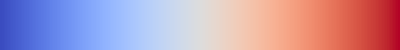

Siehe auch [seaborn-color-palettes](https://seaborn.pydata.org/tutorial/color_palettes.html)

In [ ]:
sns.pairplot(Trinkgeld, hue='sex',palette='coolwarm')

---
## Darstellung von Variablen mit Kategorien - Categorical Plots
 

### Säulendiagramme - bar charts
[Wikipedia-Säulendiagramme](https://de.wikipedia.org/wiki/S%C3%A4ulendiagramm)

[`sns.barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html)

- `x=`  Variable mit einer Kategorie
- `y=`  Variable mit kontinuierlichen Werten

Visualisierung einer groupby-Anweisung

Aggregationsmethode: standardmäßig Mittelwert (`.mean()`)

Was sind die schwarzen vertikalen Striche? -> Standard deviations

In [ ]:
sns.barplot(data=Trinkgeld,x='sex',y='total_bill')

Andere Aggregationsmethode: `estimator=`

In [ ]:
sns.barplot(data=Trinkgeld,x='sex',y='total_bill',estimator=np.median)

Darstellung der absolute Anzahl mit [`sns.countplot()`](seaborn.pydata.org/generated/seaborn.countplot.html)

In [ ]:
sns.countplot(data=Trinkgeld,x='sex')

### Boxplot - sns.boxplot()

[Wikipedia](https://de.wikipedia.org/wiki/Box-Plot)

Mit der Funktion [`sns.boxplot()`](http://seaborn.pydata.org/generated/seaborn.boxplot.html) wird ein Box-Plot erstellt. 

- x: categorial -> day : Thur, Fri, Sat, Sun
- y: numerical -> total_bill -> money $

In [ ]:
sns.boxplot(data=Trinkgeld,x='day',y='total_bill')

Einbau einer weiteren Kategorie mit dem Parameter `hue=`


In [ ]:
sns.boxplot(data=Trinkgeld,x='day',y='total_bill',hue='smoker')

weitere Diagrammtypen:
- Violineplot - sns.violoneplot()
- Stripplot - sns.stripplot()
- Swarmplot - sns.swarmplot()

---
## Matrix Plots - Heatmaps

Mit der Funktion [`sns.headmap()`](http://seaborn.pydata.org/generated/seaborn.heatmap.html) können die Werte in einer Matrix farblich dargestellt werden, z.B. Pivot-Tabellen or Korrelationen

Pandas Korrelations-Matrix - [`corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)

Wie stark sind die Spalten miteinander "verwandt", miteinander korreliert?

Anaconda Assistant Explanation:
<br>
The `pd.to_numeric()` function is used to convert the values in the DataFrame to numeric type. The `errors='coerce'` parameter ensures that any non-numeric values are converted to NaN. After converting the values, you can then calculate the correlation using the `corr()` function.

In [ ]:
Trinkgeld_tmp = Trinkgeld.apply(pd.to_numeric, errors='coerce')
Trinkgeld_tmp.corr()

In [ ]:
Trinkgeld[["total_bill","tip","size"]].corr()

In [ ]:
sns.heatmap(Trinkgeld[["total_bill","tip","size"]].corr())

Customizing mit den Parametern:
- Annotation mit Zahlenwerten in den Feldern der Matrix - `annot=True`
- Colormap - `cmap=coolwarm`

In [ ]:
sns.heatmap(Trinkgeld[["total_bill","tip","size"]].corr(), annot=True, cmap='coolwarm')